# 3E - Estabilidade: o sinal vale antes e depois da mudanca recente de regime?

**Pergunta especifica.** As relacoes sobreviventes no 3D mantem sinal e significancia em 1993-2009 e em 2010-presente?

**Objetivo.** Separar relacoes robustas de achados regime-dependentes.

**Justificativa.** Um precursor pode ser fisicamente real e ainda assim nao ser estavel para o presente. WWV, por exemplo, deve ser tratado como limite de regime se perder significancia pos-2010.

**Metodologia.** Recalcula cada relacao sobrevivente no melhor lag de 3D nos dois subperiodos, exigindo mesmo sinal e p<0,05 nos dois. Compara tambem mapas longitude x lag por subperiodo.

**Saidas.** `phase3E_estabilidade.csv`, `phase3E_mapa_diff_resumo.csv`, `phase3E_scatter_estabilidade.png`, `phase3E_mapa_lon_lag_subperiodos.png`.


In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, '.')
import fase3_utils as u
from nino_brasil.stats.significance import effective_sample_size, correlation_p_value

weekly = pd.read_csv(u.FEAT / 'phase3_indices_semanais.csv', parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
best = pd.read_csv(u.STATS / 'phase3D_ranking_significativo.csv').set_index('variavel')
P1 = ('1993-01-01','2009-12-31'); P2 = ('2010-01-01', None)

def corr_at(w, col, lag):
    x = w[col].shift(lag); y = w['nino34_ssta']
    m = x.notna() & y.notna()
    if m.sum() < 80: return np.nan, np.nan, 0
    r = float(np.corrcoef(x[m], y[m])[0,1])
    p = correlation_p_value(r, effective_sample_size(x[m].values, y[m].values))
    return r, p, int(m.sum())

rows = []
for var, row in best.iterrows():
    lag = int(row['lag_semanas'])
    w1 = weekly.loc[P1[0]:P1[1]]; w2 = weekly.loc[P2[0]:]
    r1, p1, n1 = corr_at(w1, var, lag)
    r2, p2, n2 = corr_at(w2, var, lag)
    estavel = (np.sign(r1) == np.sign(r2)) and (p1 < 0.05) and (p2 < 0.05)
    rows.append({'variavel': var, 'lag_semanas': lag, 'r_full': round(row['r'],3),
                 'r_1993_2009': round(r1,3), 'p_1993_2009': round(p1,4), 'n1': n1,
                 'r_2010_hoje': round(r2,3), 'p_2010_hoje': round(p2,4), 'n2': n2,
                 'estavel': bool(estavel)})
est = pd.DataFrame(rows).set_index('variavel')
u.save_table(est, 'phase3E_estabilidade.csv')
print(f"estaveis: {int(est['estavel'].sum())} de {len(est)}")
est

[tabela] data\processed\parquet\statistics\phase3E_estabilidade.csv
estaveis: 7 de 9


,lag_semanas,r_full,r_1993_2009,p_1993_2009,n1,r_2010_hoje,p_2010_hoje,n2,estavel
variavel,,,,,,,,,
tilt_m,0,0.772,0.803,0.0006,887,0.807,0.0008,859,True
ssh_m,6,0.755,0.781,0.0002,881,0.757,0.0005,853,True
ohc_0_300,6,0.738,0.745,0.0011,881,0.728,0.0019,853,True
ohc_0_700,6,0.701,0.713,0.0015,881,0.689,0.0024,853,True
dhw_12w,0,0.612,0.540,0.0767,887,0.669,0.0306,859,False
d20_m,15,0.545,0.546,0.0323,872,0.527,0.0404,844,True
wwv,20,0.516,0.558,0.0479,867,0.483,0.1095,839,False
tau_x_proxy_nino34_pa,1,0.442,0.409,0.0000,886,0.512,0.0000,858,True
atl4_ssta,25,-0.265,-0.313,0.0007,862,-0.366,0.0088,834,True


[figura] data\processed\figures\fase3\phase3E_scatter_estabilidade.png


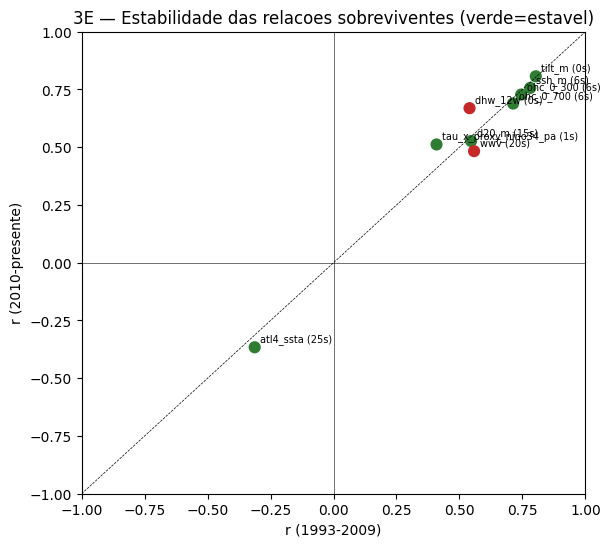

In [2]:
# Figura 3E-1: r subperiodo 1 x subperiodo 2
fig, ax = plt.subplots(figsize=(6.5, 6))
colors = est['estavel'].map({True: '#2e7d32', False: '#c62828'})
ax.scatter(est['r_1993_2009'], est['r_2010_hoje'], c=colors, s=60)
for var, row in est.iterrows():
    ax.annotate(f"{var} ({row['lag_semanas']}s)", (row['r_1993_2009'], row['r_2010_hoje']), fontsize=7,
                xytext=(4,4), textcoords='offset points')
lim = [-1, 1]
ax.plot(lim, lim, 'k--', lw=0.5); ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('r (1993-2009)'); ax.set_ylabel('r (2010-presente)')
ax.set_title('3E — Estabilidade das relacoes sobreviventes (verde=estavel)')
u.save_fig(fig, 'phase3E_scatter_estabilidade.png')
plt.show()

[figura] data\processed\figures\fase3\phase3E_mapa_lon_lag_subperiodos.png
[tabela] phase3E_mapa_diff_resumo.csv | diff medio |r1-r2| = 0.104


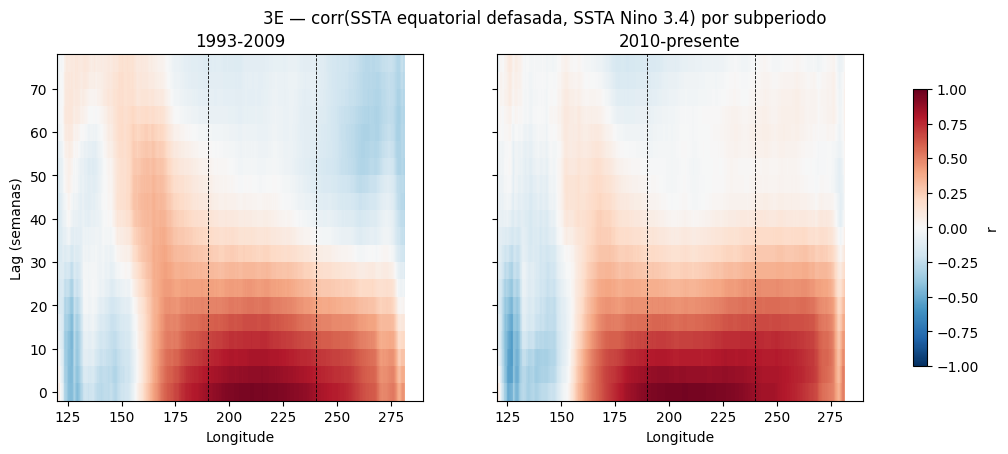

In [3]:
# Mapa 3E-1: lon x lag por subperiodo
eq = u.load_eqband_weekly()
def lonlag(eqd, tgt, lags):
    eq_al, t_al = eqd.align(tgt, join='inner', axis=0)
    tv = t_al.values
    out = np.full((len(lags), eq_al.shape[1]), np.nan)
    for i, lag in enumerate(lags):
        sh = eq_al.shift(lag).values
        for j in range(eq_al.shape[1]):
            x = sh[:, j]; m = np.isfinite(x) & np.isfinite(tv)
            if m.sum() > 80: out[i,j] = np.corrcoef(x[m], tv[m])[0,1]
    return out, eq_al.columns.values
lags_map = list(range(0, 79, 4))
tgt = weekly['nino34_ssta']
A, lon = lonlag(eq.loc[P1[0]:P1[1]], tgt.loc[P1[0]:P1[1]], lags_map)
B, _ = lonlag(eq.loc[P2[0]:], tgt.loc[P2[0]:], lags_map)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, mat, ttl in [(axes[0], A, '1993-2009'), (axes[1], B, '2010-presente')]:
    pc = ax.pcolormesh(lon, lags_map, mat, cmap='RdBu_r', vmin=-1, vmax=1, shading='auto')
    ax.axvline(190, color='k', ls='--', lw=0.6); ax.axvline(240, color='k', ls='--', lw=0.6)
    ax.invert_yaxis(); ax.set_title(ttl); ax.set_xlabel('Longitude')
axes[0].set_ylabel('Lag (semanas)')
fig.suptitle('3E — corr(SSTA equatorial defasada, SSTA Nino 3.4) por subperiodo')
fig.colorbar(pc, ax=axes, label='r', shrink=0.8)
u.save_fig(fig, 'phase3E_mapa_lon_lag_subperiodos.png')
np.save(u.STATS / 'phase3E_lonlag_p1.npy', A); np.save(u.STATS / 'phase3E_lonlag_p2.npy', B)
pd.DataFrame({'diff_medio_abs': [float(np.nanmean(np.abs(A-B)))]}).to_csv(u.STATS / 'phase3E_mapa_diff_resumo.csv', index=False)
print('[tabela] phase3E_mapa_diff_resumo.csv | diff medio |r1-r2| =', round(float(np.nanmean(np.abs(A-B))),3))
plt.show()

**Leitura do 3E.** Somente as relações verdes (mesmo sinal e significância nos dois regimes) são utilizáveis no parecer — as demais, ainda que fortes no período completo, podem refletir um regime específico (ex.: mudanças pós-2010 na relação WWV→SSTA documentadas na literatura). A comparação dos mapas lon×lag entre subperíodos indica se a estrutura de propagação oeste→leste se manteve. **Conjunto final do parecer = sobreviventes do 3D ∩ estáveis do 3E.**